In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [3]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [5]:
x_train.shape ,x_test.shape

((60000, 28, 28), (10000, 28, 28))

In [7]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [8]:
x_train.shape ,x_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [9]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [12]:
history = model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9926 - loss: 0.0233 - val_accuracy: 0.9907 - val_loss: 0.0294
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9946 - loss: 0.0174 - val_accuracy: 0.9885 - val_loss: 0.0359
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.9918 - val_loss: 0.0288
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9963 - loss: 0.0111 - val_accuracy: 0.9907 - val_loss: 0.0328
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9966 - loss: 0.0094 - val_accuracy: 0.9919 - val_loss: 0.0376


In [15]:
model.save("/content/drive/MyDrive/models/cnn_mnist_model.keras")

In [20]:
history.history.items()

dict_items([('accuracy', [0.9925666451454163, 0.9945833086967468, 0.9955999851226807, 0.9963499903678894, 0.996649980545044]), ('loss', [0.023257018998265266, 0.017448998987674713, 0.013753525912761688, 0.011114783585071564, 0.00941565539687872]), ('val_accuracy', [0.9907000064849854, 0.9884999990463257, 0.9918000102043152, 0.9907000064849854, 0.9919000267982483]), ('val_loss', [0.029400531202554703, 0.03591085970401764, 0.028751956298947334, 0.032803975045681, 0.03760753199458122])])

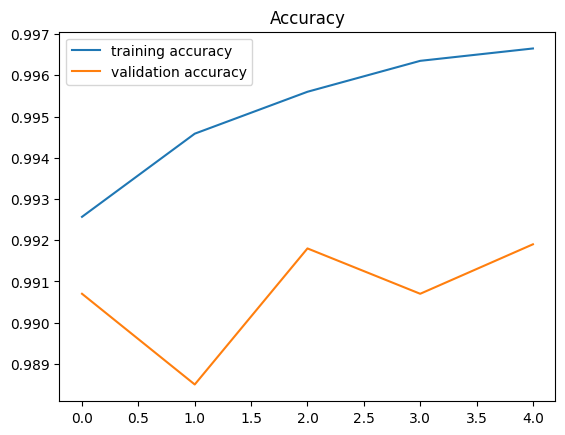

In [22]:
plt.plot(history.history["accuracy"] , label = "training accuracy")
plt.plot(history.history["val_accuracy"] , label = "validation accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()


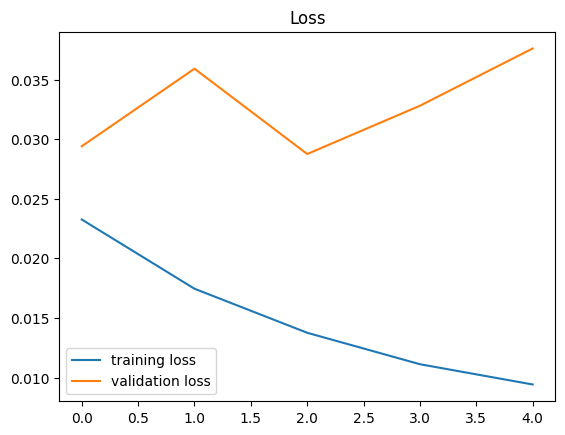

In [23]:
plt.plot(history.history["loss"] , label = "training loss")
plt.plot(history.history["val_loss"] , label = "validation loss")
plt.title("Loss")
plt.legend()
plt.show()


In [3]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/models/cnn_mnist_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


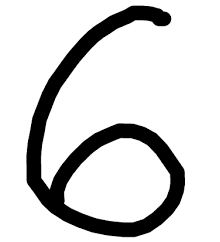

In [32]:
img = Image.open("/content/drive/MyDrive/models/test.png").convert('L')
img

In [24]:
img = img.resize((28, 28))

In [25]:
img

In [26]:
img_array = np.array(img)
img_array = 255 - img_array
img_array

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,  61,  96,  89,  59,  11,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          9,  89, 183, 255, 255, 255, 255, 211,  96,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  71,
        204, 255, 251, 176,  93,  95, 171, 242, 160,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   9, 148, 255,
        253, 146,  39,   0,   0,   0,   0,  24,   5,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  13, 178, 255, 201,
         56,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  10, 178, 255, 175,  15,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   1, 159, 255, 178,  10,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 117, 255, 199,  15,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  71, 250, 230,  36,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  21, 225, 250,  74,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 133, 255, 140,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  20, 234, 236,  24,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 105, 255, 147,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   4, 202, 250,  48,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  28, 247, 209,   2,   0,   0,   0,   0,   0,   0,
         49, 135, 181, 177, 140,  66,   1,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,  67, 255, 162,   0,   0,   0,   0,   0,  64, 186,
        255, 255, 243, 244, 255, 255, 186,  37,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 116, 255, 108,   0,   0,   0,   1, 129, 254, 255,
        175,  78,  22,  22,  62, 169, 255, 219,  40,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 149, 255,  73,   0,   0,   7, 156, 255, 215,  66,
          0,   0,   0,   0,   0,   0, 126, 255, 204,  14,   0,   0,   0,
          0,   0],
       [  0,   0,   0, 162, 255,  61,   0,   2, 155, 255, 194,  27,   0,
          0,   0,   0,   0,   0,   0,   0, 157, 255, 155,   1,   0,   0,
          0,   0],
       [  0,   0,   0, 158, 255,  63,   0, 115, 255, 201,  19,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  15, 203, 255,  85,   0,   0,
          0,   0],
       [  0,   0,   0, 160, 255,  77,  31, 244, 233,  36,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,  88, 255, 139,   0,   0,
          0,   0],
       [  0,   0,   0,  83, 253, 211, 159, 255, 113,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,  94, 255, 129,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 132, 255, 255, 254,  47,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0, 174, 255,  74,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   5, 174, 255, 255,  92,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  99, 255, 210,  10,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   9, 14

In [27]:
img_array = img_array / 255.0
img_array

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.23921569, 0.37647059, 0.34901961, 0.23137255,
        0.04313725, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.03529412, 0.34901961,
        0.71764706, 1.        , 1.        , 1.        , 1.        ,
        0.82745098, 0.37647059, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.27843137, 0.8       , 1.        ,
        0.98431373, 0.6901

In [28]:
img_array = img_array.reshape(1, 28, 28, 1)
img_array.shape

(1, 28, 28, 1)

In [29]:
prediction = loaded_model.predict(img_array)
predicted_label = np.argmax(prediction)

print("Predicted Digit:", predicted_label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Predicted Digit: 6


In [33]:
prediction

array([[2.2061280e-07, 5.7641596e-11, 9.0064939e-05, 1.2083023e-06,
        4.2936668e-07, 1.1979853e-07, 6.4153248e-01, 1.0633067e-16,
        3.5837522e-01, 2.3678818e-07]], dtype=float32)